# Librerías

In [2]:
import os
import logging

# Bloque para ignorar warnings de sistema y de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'              # Bloquea avisos de TF (1=INFO, 2=WARNING, 3=FATAL)
logging.getLogger('tensorflow').setLevel(logging.ERROR) # Silencia avisos de deprecación internos

# Importacion de librerias
import numpy as np                                    # Manejo de vectores y matrices
import pandas as pd                                   # Manipulación de tablas de datos
import matplotlib.pyplot as plt                       # Visualización y gráficas

from sklearn.model_selection import train_test_split  # División del dataset en train/test

import tensorflow as tf                               # Biblioteca principal de IA
from tensorflow.keras.preprocessing.text import Tokenizer      # Conversión de texto a números
from tensorflow.keras.preprocessing.sequence import pad_sequences # Estandarización de longitud de texto
from tensorflow.keras.models import Sequential                 # Contenedor de capas secuenciales
from tensorflow.keras.layers import Embedding         # Capa para representación vectorial de palabras
from tensorflow.keras.layers import Dense             # Capa neuronal densa/completamente conectada
from tensorflow.keras.layers import GlobalAveragePooling1D # Capa de reducción de dimensionalidad
from tensorflow.keras.layers import SimpleRNN         # Capa de Red Neuronal Recurrente básica
from tensorflow.keras.layers import Input             # Definición de la entrada del modelo
from tensorflow.keras.optimizers import Adam          # Algoritmo de optimización del aprendizaje

# Fijamos semillas de aleatoriedad fija
np.random.seed(42)                                    # Consistencia en procesos aleatorios de Numpy
tf.random.set_seed(42)                                # Consistencia en pesos iniciales de TensorFlow

# Datasets

**Corpus de texto:** Lista de frases de ejemplo

In [5]:
frases = [
    "me gusta esta pelicula", "no me gusta esta pelicula", "esta pelicula es buena", "esta pelicula no es buena",
    "me encanta este restaurante", "no me encanta este restaurante", "el sistema no es malo",
    "este restaurante es bueno", "este restaurante no es bueno",    "el servicio fue excelente", "el servicio no fue excelente",
    "la comida estuvo deliciosa", "la comida no estuvo deliciosa",    "amo esta cancion", "no amo esta cancion", "este libro es interesante",
    "este libro no es interesante", "el curso fue util",    "el curso no fue util", "me parece fantastico",
    "no me parece fantastico", "la experiencia fue agradable",    "la experiencia no fue agradable", "me gusta mucho este lugar",
    "no me gusta mucho este lugar", "el producto funciona bien",    "el producto no funciona bien", "la app es rapida",
    "la app no es rapida", "el hotel fue comodo",    "el hotel no fue comodo", "la pelicula fue aburrida",
    "la pelicula no fue aburrida", "el restaurante fue terrible",    "el restaurante no fue terrible", "la clase estuvo confusa",
    "la clase no estuvo confusa", "el libro fue pesado",    "el libro no fue pesado", "el sistema es malo"
]
frases[:3] # Visualización de los primeros 3 elementos de la lista

['me gusta esta pelicula',
 'no me gusta esta pelicula',
 'esta pelicula es buena']

**Etiquetas:** Para claificar el tipo de sentimiento

$1$ Sentimineto positivo.

$0$ Sentimiento negativo.

In [7]:
# Se mapean 1 a 1 con la lista de frases de arriba
etiquetas = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1
] # Lista binaria que representa el sentimiento de cada frase
etiquetas[:3]

[1, 0, 1]

Unificamos los datos en un DataFrame para facilitar el análisis

In [9]:
# Unificamos los datos en un DataFrame para facilitar el análisis
df = pd.DataFrame({
    'frase': frases,                                  # Columna de entrada (características)
    'etiqueta': etiquetas                             # Columna de salida (objetivo/target)
})
# Visualización con formato
print("--- Primeras 10 muestras ---")
print(df.head(10).to_string(index=False))             # Mostramos el inicio sin el índice de fila
print("-" * 30)

--- Primeras 10 muestras ---
                         frase  etiqueta
        me gusta esta pelicula         1
     no me gusta esta pelicula         0
        esta pelicula es buena         1
     esta pelicula no es buena         0
   me encanta este restaurante         1
no me encanta este restaurante         0
         el sistema no es malo         1
     este restaurante es bueno         0
  este restaurante no es bueno         1
     el servicio fue excelente         0
------------------------------


Observamos que tenenemos un dataset balanceado

In [11]:
# Resumen rápido del dataset
print(f"Total de ejemplos: {len(df)}")                # Cantidad total de datos
print(df['etiqueta'].value_counts())                  # Conteo de ejemplos por clase
print(df['etiqueta'].value_counts(normalize=True) * 100) # Porcentaje de cada clase en el total

Total de ejemplos: 40
etiqueta
1    20
0    20
Name: count, dtype: int64
etiqueta
1    50.0
0    50.0
Name: proportion, dtype: float64


# Modelo

In [13]:
# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(
    frases,                                           # Datos de entrada (textos)
    etiquetas,                                        # Datos de salida (clases 0 y 1)
    test_size=.25,                                    # Reservamos el 25% para validación
    stratify=etiquetas                                # Mantiene la proporción original de clases
)

print("Numero de frases de entrenamiento:", len(X_train)) # Tamaño del set para aprender
print("Numero de frases de prueba:", len(X_test))         # Tamaño del set para evaluar

Numero de frases de entrenamiento: 30
Numero de frases de prueba: 10


## 1. Tokenización

In [15]:
# 1. Instanciamos el Tokenizer
# oov_token: Palabra especial para representar términos que no estén en el vocabulario durante el test
tokenizer = Tokenizer( oov_token="<OOV>")

# 2. Ajustamos el tokenizador SOLAMENTE con los datos de entrenamiento
# Esto construye el diccionario de palabras basándose en X_train
tokenizer.fit_on_texts(X_train)

# 3, Extraemos el diccionario de mapeo generado por el Tokenizer
# La llave es la palabra y el valor es su índice numérico
word_index = tokenizer.word_index

# Mostramos el tamaño real del vocabulario encontrado y un ejemplo
print(f"Total de palabras únicas encontradas: {len(word_index)}")
print("Ejemplo del índice para '<OOV>':", word_index.get("<OOV>"))

Total de palabras únicas encontradas: 43
Ejemplo del índice para '<OOV>': 1


In [16]:
# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

Índice     | Palabra             
-----------------------------------
1          | <OOV>               
2          | no                  
3          | el                  
4          | fue                 
5          | me                  
6          | es                  
7          | la                  
8          | este                
9          | restaurante         
10         | pelicula            
11         | esta                
12         | estuvo              
13         | gusta               
14         | encanta             
15         | sistema             
16         | malo                
17         | curso               
18         | util                
19         | aburrida            
20         | comida              
21         | deliciosa           
22         | app                 
23         | rapida              
24         | terrible            
25         | servicio            
-----------------------------------


## 2. Secuencias - Padding

In [18]:
# =========================================================
# 4. Conversión de frases a secuencias numéricas
# =========================================================

# texts_to_sequences sustituye cada palabra por su número de diccionario
X_train_seq = tokenizer.texts_to_sequences(X_train)   # Transforma el texto de entrenamiento en listas de enteros
X_test_seq = tokenizer.texts_to_sequences(X_test)     # Transforma el texto de prueba usando el mismo diccionario

print("Ejemplo de frase original:", X_train[0])        # Muestra la primera oración en formato texto
print("Ejemplo de frase convertida:", X_train_seq[0])  # Muestra la misma oración como secuencia de números

Ejemplo de frase original: me encanta este restaurante
Ejemplo de frase convertida: [5, 14, 8, 9]


Observamos las $5$ primeras frases del entrenamiento después de tenerlas en lista de enteros.

In [20]:
X_train_seq[:5] 

[[5, 14, 8, 9],
 [3, 15, 6, 16],
 [3, 17, 4, 18],
 [2, 34, 11, 35],
 [7, 10, 2, 4, 19]]

In [21]:
# Calculamos la longitud máxima observada en cada conjunto
# La list comprehension dentro de max() recorre cada secuencia y mide su len()
max_train = max([len(x) for x in X_train_seq])
max_test = max([len(x) for x in X_test_seq])

# Imprimimos los resultados para definir nuestro maxlen del padding
print(f"Longitud máxima en entrenamiento: {max_train}")
print(f"Longitud máxima en prueba: {max_test}")

Longitud máxima en entrenamiento: 6
Longitud máxima en prueba: 5



> **Nota:** Se utiliza siempre la longitud de **entrenamiento** para asegurar que el modelo tenga un tamaño de entrada fijo y no "contaminarlo" con información del conjunto de prueba (evitando el *Data Leakage*). Si una frase de prueba es más larga, simplemente se recorta para ajustarse al estándar que el modelo aprendió.

In [23]:
# Buscamos la longitud de la oración con más palabras
max_len = max(len(seq) for seq in X_train_seq)         # Calcula el tamaño de la frase más larga del corpus
print("\nLongitud máxima encontrada:", max_len)       # Reporta el estándar de ancho para todas las secuencias


Longitud máxima encontrada: 6


In [24]:
# =========================================================
# 5. Normalización de longitud (Padding)
# =========================================================
# Pad_sequences rellena con ceros las oraciones cortas
# padding="post" significa que pone los ceros al final (a la derecha)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post") # Nivela el tamaño en el set de entrenamiento
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")   # Nivela el tamaño en el set de prueba

Observamos las $5$ primeras frases del entrenamiento después de aplicar **padding**

In [26]:
X_train_pad[:5] 

array([[ 5, 14,  8,  9,  0,  0],
       [ 3, 15,  6, 16,  0,  0],
       [ 3, 17,  4, 18,  0,  0],
       [ 2, 34, 11, 35,  0,  0],
       [ 7, 10,  2,  4, 19,  0]])

Obtenemos el tamaño de <code> X_train_pad </code>

In [28]:
print("Forma de X_train_pad:", X_train_pad.shape)     # Indica el número de frases y la longitud de cada una

Forma de X_train_pad: (30, 6)


In [29]:
# Le sumamos 1 al vocabulario porque Keras usa el número 0 para el padding
vocab_size = len(word_index) + 1                      # Tamaño total: palabras únicas + token de relleno

# Decidimos que cada palabra se representará con un vector de 16 dimensiones
embedding_dim = 16                                    # Espacio vectorial para capturar semántica de palabras

## Modelo base (sin memoria)

**Embedding o incrustación** es un medio para representar objetos como texto, imágenes y audio como puntos en un espacio vectorial continuo donde las ubicaciones de esos puntos en el espacio son semánticamente significativas.

**Embedding** es una herramienta fundamental para los ingenieros de machine learning (ML) que crean motores de búsqueda de texto e imágenes, sistemas de recomendación, chatbots, sistemas de detección de fraudes y muchas otras aplicaciones. En esencia, las incrustaciones permiten que los modelos de machine learning encuentren objetos similares.

In [32]:
# =========================================================
# 7. Construcción del Modelo Base (Sin Memoria)
# =========================================================


# Creamos un modelo secuencial (arquitectura capa tras capa)
modelo_base = Sequential([
    # Declaramos explícitamente la forma de la entrada (longitud de la frase)
    Input(shape=(max_len,)),                          # Define cuántos números recibirá el modelo por frase
    
    # Capa 1: Embedding. Convierte números enteros en vectores densos
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), 
    
    # Capa 2: Promedio. Reduce la dimensión promediando los vectores de la oración
    # Nota: Aquí se pierde el orden gramatical de las palabras
    GlobalAveragePooling1D(), 
    
    # Capa 3: Capa densa intermedia para aprendizaje de patrones complejos
    Dense(16, activation="relu"),                     # 16 neuronas con activación ReLU para no linealidad
    
    # Capa 4: Salida. Un solo valor que representa la probabilidad (0 a 1)
    Dense(1, activation="sigmoid")                    # Sigmoid es estándar para clasificación binaria
])

# =========================================================
# 8. Configuración del entrenamiento (Compilación)
# =========================================================

modelo_base.compile(
    optimizer=Adam(learning_rate=0.001),              # Algoritmo Adam para optimizar pesos eficientemente
    loss="binary_crossentropy",                       # Función de pérdida específica para etiquetas 0/1
    metrics=["accuracy"]                              # Métrica para observar el porcentaje de precisión
)

# Visualización de la arquitectura y número de parámetros
modelo_base.summary()                                 # Imprime el resumen estructural del modelo


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 6, 16)             704       
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 993 (3.88 KB)
Trainable params: 993 (3.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [33]:
# =========================================================
# 9. Ejecución del Entrenamiento (Ajuste de Pesos)
# =========================================================

# Entrenamos el modelo base
hist_base = modelo_base.fit(
    X_train_pad,                                      # Matriz de frases procesadas (IDs + Padding)
    np.array(y_train),                                # Etiquetas reales convertidas a formato Numpy
    epochs=40,                                        # Ciclos completos de aprendizaje sobre el dataset
    validation_split=0.25,                            # Reserva el 25% de estos datos para evaluar sin sesgos
    verbose=1                                         # Muestra el progreso (pérdida y precisión) en consola
)

print("\nEntrenamiento del modelo base completado")    # Confirmación de finalización del proceso

Epoch 1/40


1/1 [==============================] - 3s 3s/step - loss: 0.6938 - accuracy: 0.5000 - val_loss: 0.6929 - val_accuracy: 0.5000
Epoch 2/40
1/1 [==============================] - 0s 80ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 3/40
1/1 [==============================] - 0s 80ms/step - loss: 0.6925 - accuracy: 0.5909 - val_loss: 0.6939 - val_accuracy: 0.5000
Epoch 4/40
1/1 [==============================] - 0s 83ms/step - loss: 0.6918 - accuracy: 0.6364 - val_loss: 0.6944 - val_accuracy: 0.5000
Epoch 5/40
1/1 [==============================] - 0s 80ms/step - loss: 0.6912 - accuracy: 0.6364 - val_loss: 0.6949 - val_accuracy: 0.5000
Epoch 6/40
1/1 [==============================] - 0s 69ms/step - loss: 0.6905 - accuracy: 0.6364 - val_loss: 0.6953 - val_accuracy: 0.3750
Epoch 7/40
1/1 [==============================] - 0s 67ms/step - loss: 0.6899 - accuracy: 0.7273 - val_loss: 0.6959 - val_accuracy: 0.2500
Epoch 8/40
1/1 [===========

## Modelo base (con memoria)

In [35]:
# =========================================================
# 10. Construcción del Modelo con RNN (Con Memoria)
# =========================================================

# Creamos un modelo secuencial que utiliza recursividad
modelo_rnn = Sequential([
    # Entrada con la longitud máxima definida anteriormente
    Input(shape=(max_len,)),                          # Recibe las secuencias de números (IDs)
    
    # Capa 1: Embedding. Traduce IDs a vectores de significado
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), 
    
    # Capa 2: SimpleRNN. Procesa las palabras una por una en orden
    # A diferencia del promedio, esta capa mantiene un "estado" que recuerda lo anterior
    SimpleRNN(16, activation="tanh"),                 # 16 neuronas recurrentes; tanh es el estándar aquí
    
    # Capa 3: Salida. Clasificación final
    Dense(1, activation="sigmoid")                    # Entrega la probabilidad de sentimiento (0 a 1)
])

# =========================================================
# 11. Compilación del Modelo RNN
# =========================================================

modelo_rnn.compile(
    optimizer=Adam(learning_rate=0.001),              # Optimizador Adam para el ajuste de pesos
    loss="binary_crossentropy",                       # Función de pérdida para etiquetas binarias
    metrics=["accuracy"]                              # Reporte de precisión durante el entrenamiento
)

# Visualización de la arquitectura recurrente
modelo_rnn.summary()                                 # Muestra el resumen de capas y parámetros

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 6, 16)             704       
                                                                 
 simple_rnn (SimpleRNN)      (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1249 (4.88 KB)
Trainable params: 1249 (4.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
# =========================================================
# 12. Ejecución del Entrenamiento de la RNN
# =========================================================

# Entrenamos el modelo con capacidad secuencial (memoria)
hist_rnn = modelo_rnn.fit(
    X_train_pad,                                      # Datos de entrenamiento con relleno (padding)
    np.array(y_train),                                # Etiquetas reales en formato arreglo de Numpy
    epochs=40,                                        # Número de pasadas completas por el dataset
    validation_split=0.25,                            # Reserva el 25% para validar el aprendizaje secuencial
    verbose=1                                         # Muestra el progreso detallado en cada época
)

print("\nEntrenamiento del modelo RNN completado")     # Confirmación de cierre del segundo entrenamiento

Epoch 1/40
1/1 [==============================] - 5s 5s/step - loss: 0.6838 - accuracy: 0.5909 - val_loss: 0.7221 - val_accuracy: 0.2500
Epoch 2/40
1/1 [==============================] - 0s 80ms/step - loss: 0.6796 - accuracy: 0.6818 - val_loss: 0.7226 - val_accuracy: 0.1250
Epoch 3/40
1/1 [==============================] - 0s 84ms/step - loss: 0.6753 - accuracy: 0.6818 - val_loss: 0.7234 - val_accuracy: 0.1250
Epoch 4/40
1/1 [==============================] - 0s 82ms/step - loss: 0.6710 - accuracy: 0.7727 - val_loss: 0.7243 - val_accuracy: 0.1250
Epoch 5/40
1/1 [==============================] - 0s 74ms/step - loss: 0.6666 - accuracy: 0.8182 - val_loss: 0.7255 - val_accuracy: 0.1250
Epoch 6/40
1/1 [==============================] - 0s 123ms/step - loss: 0.6622 - accuracy: 0.8182 - val_loss: 0.7268 - val_accuracy: 0.1250
Epoch 7/40
1/1 [==============================] - 0s 102ms/step - loss: 0.6576 - accuracy: 0.8636 - val_loss: 0.7284 - val_accuracy: 0.1250
Epoch 8/40
1/1 [===========

## Visualización

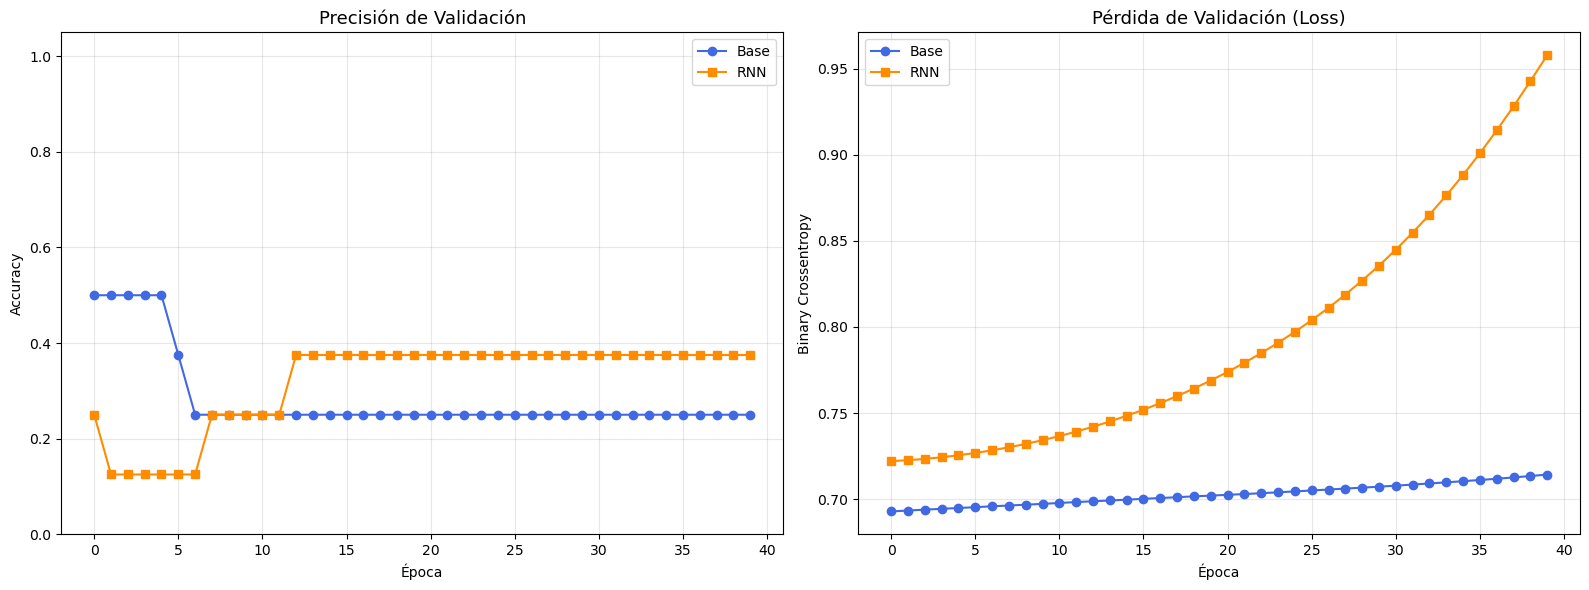

In [67]:
# =========================================================
# 13. Comparación de Métricas: Precisión y Pérdida
# =========================================================

# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Precisión (Accuracy) ---
ax1.plot(hist_base.history["val_accuracy"], label="Base", marker='o', color='royalblue')
ax1.plot(hist_rnn.history["val_accuracy"], label="RNN", marker='s', color='darkorange')
ax1.set_title("Precisión de Validación", fontsize=13)  # Título del primer panel
ax1.set_xlabel("Época")                                # Eje X: tiempo
ax1.set_ylabel("Accuracy")                             # Eje Y: porcentaje de acierto
ax1.set_ylim(0, 1.05)                                  # Rango fijo para evitar escalas confusas
ax1.legend()                                           # Muestra las etiquetas de los modelos
ax1.grid(True, alpha=0.3)                              # Cuadrícula suave

# --- GRÁFICO 2: Pérdida (Loss) ---
ax2.plot(hist_base.history["val_loss"], label="Base", marker='o', color='royalblue')
ax2.plot(hist_rnn.history["val_loss"], label="RNN", marker='s', color='darkorange')
ax2.set_title("Pérdida de Validación (Loss)", fontsize=13) # Título del segundo panel
ax2.set_xlabel("Época")                                # Eje X: tiempo
ax2.set_ylabel("Binary Crossentropy")                  # Eje Y: nivel de error
ax2.legend()                                           # Muestra las etiquetas
ax2.grid(True, alpha=0.3)                              # Cuadrícula suave

# Ajuste final de layout y visualización
plt.tight_layout()                                     # Evita que se encimen los títulos
plt.show()                                             # Renderiza ambos paneles

In [69]:
# =========================================================
# 14. Evaluación Final sobre Datos No Vistos (Test Set)
# =========================================================

# Evaluamos ambos modelos en el conjunto de prueba (que no usaron para entrenar)
loss_base, acc_base = modelo_base.evaluate(X_test_pad, np.array(y_test), verbose=0)
loss_rnn, acc_rnn = modelo_rnn.evaluate(X_test_pad, np.array(y_test), verbose=0)

# Mostramos los resultados de forma estructurada
print("-" * 45)
print(f"{'MODELO':<20} | {'LOSS':<10} | {'ACCURACY':<10}")
print("-" * 45)
print(f"{'Modelo Base':<20} | {loss_base:<10.4f} | {acc_base*100:<9.2f}%")
print(f"{'Modelo RNN':<20} | {loss_rnn:<10.4f} | {acc_rnn*100:<9.2f}%")
print("-" * 45)

# 15. Conclusión automática del desempeño
mejor_modelo = "Modelo RNN" if acc_rnn > acc_base else "Modelo Base"
diferencia = abs(acc_rnn - acc_base) * 100

print(f"Ganador: {mejor_modelo} (por una diferencia de {diferencia:.2f}%)")

---------------------------------------------
MODELO               | LOSS       | ACCURACY  
---------------------------------------------
Modelo Base          | 0.6992     | 60.00    %
Modelo RNN           | 0.6336     | 60.00    %
---------------------------------------------
Ganador: Modelo Base (por una diferencia de 0.00%)


In [72]:
# =========================================================
# 16. Inferencia: Pruebas en Tiempo Real
# =========================================================

frases_nuevas = [
    "me gusta este libro", "no me gusta este libro",    "esta pelicula es buena",    "esta pelicula es mala",
    "el sistema es malo",    "el sistema no es malo",    "la app es rapida",    "la app no es rapida"
]

# Preprocesamiento de las frases nuevas
seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)         # Convierte a IDs usando el mismo diccionario
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post") # Ajusta al tamaño de entrada del modelo

# Obtención de predicciones (Probabilidades entre 0 y 1)
pred_base = modelo_base.predict(pad_nuevas, verbose=0)
pred_rnn = modelo_rnn.predict(pad_nuevas, verbose=0)

print(f"{'SENTIMIENTO REAL / FRASE':<30} | {'BASE':<12} | {'RNN':<12}")
print("-" * 65)

for i, frase in enumerate(frases_nuevas):
    # Determinamos el emoji según la predicción de la RNN (que suele ser más precisa)
    sentimiento = "😊" if pred_rnn[i][0] > 0.5 else "😡"
    
    # Formateamos los resultados para comparación directa
    res_base = f"{pred_base[i][0]:.3f}"
    res_rnn  = f"{pred_rnn[i][0]:.3f}"
    
    print(f"{sentimiento} {frase[:27]:<27} | {res_base:<12} | {res_rnn:<12}")

print("-" * 65)
print("Nota: Valores > 0.5 son Positivos | Valores < 0.5 son Negativos")

SENTIMIENTO REAL / FRASE       | BASE         | RNN         
-----------------------------------------------------------------
😊 me gusta este libro         | 0.476        | 0.680       
😡 no me gusta este libro      | 0.503        | 0.396       
😡 esta pelicula es buena      | 0.474        | 0.396       
😡 esta pelicula es mala       | 0.478        | 0.356       
😊 el sistema es malo          | 0.514        | 0.636       
😊 el sistema no es malo       | 0.531        | 0.816       
😡 la app es rapida            | 0.478        | 0.202       
😊 la app no es rapida         | 0.508        | 0.623       
-----------------------------------------------------------------
Nota: Valores > 0.5 son Positivos | Valores < 0.5 son Negativos
